Model Comparison Results:
                    CV F1 Mean (±Std) Test Accuracy Test Precision  \
Logistic Regression    0.560 (±0.007)         0.723          0.464   
Decision Tree          0.577 (±0.006)         0.728          0.471   
Random Forest          0.576 (±0.005)         0.730          0.473   

                    Test Recall Test F1  
Logistic Regression       0.724   0.566  
Decision Tree             0.757   0.581  
Random Forest             0.754   0.581  

MODEL FORMULAS / RULES

--- Logistic Regression ---
Logistic Regression (log-odds):
   log(p / (1-p)) =   0.0666
                 +   0.5801 * age
                 +  -1.5974 * education_category_HS Graduate
                 +  -2.8606 * education_category_Less than HS
                 +  -1.1218 * education_category_Some College
                 +   1.2436 * sex_Male
(p = probability of income > $50K)

--- Decision Tree ---
Decision Tree rules (first 5 levels):
|--- age <= -0.80
|   |--- age <= -1.10
|   |   |--- age 

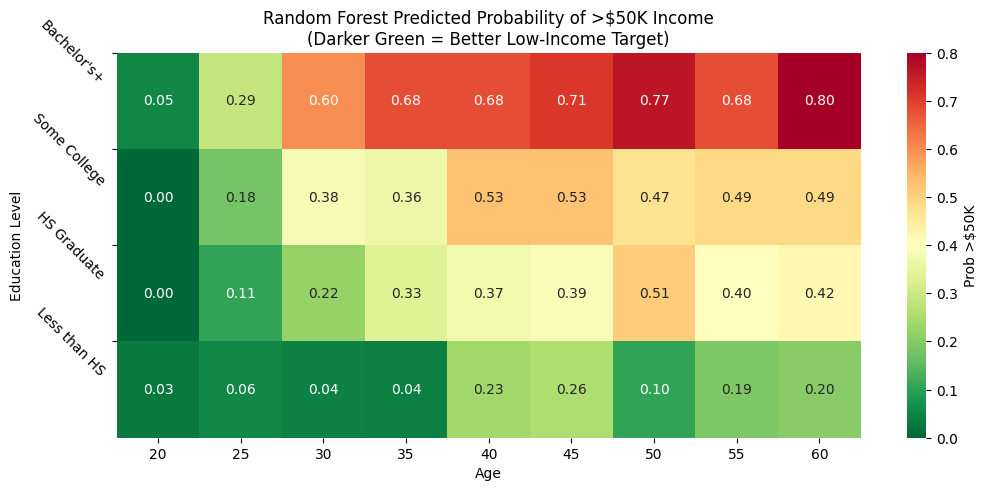

In [14]:
# Import libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from itertools import product
import matplotlib.pyplot as plt
import seaborn as sns

# Load cleaned data
df = pd.read_csv('df_cleaned.csv')

# === EDUCATION BINNING (4 categories only) ===
def categorize_education(edu):
    """Simplify education levels into 4 meaningful groups."""
    less_than_hs = ['Preschool', '1st-4th', '5th-6th', '7th-8th', '9th', '10th', '11th', '12th']
    hs_grad = ['HS-grad']
    some_college = ['Some-college', 'Assoc-acdm', 'Assoc-voc']
    bachelors_plus = ['Bachelors', 'Masters', 'Prof-school', 'Doctorate']

    if edu in less_than_hs:
        return 'Less than HS'
    elif edu in hs_grad:
        return 'HS Graduate'
    elif edu in some_college:
        return 'Some College'
    else:
        return "Bachelor's+"

# Apply the binning
df['education_category'] = df['education'].apply(categorize_education)

# === FEATURES (now using binned education) ===
features = ['age', 'education_category', 'sex']
X = df[features]
y = df['income_binary']

# Identify column types
categorical_features = ['education_category', 'sex']
numeric_features = ['age']

# Preprocessor: This code is used to transform data with mixed data (e.g. numerical, catergorical)
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features), # Scales numeric features to mean = 0, std_dev = 1
        # OneHotEncoder converts categorical information to arbitrary binary values
         ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_features)
    ])

# Train-test split (stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Create a library with three models: Logistic Regression, Decision Tree, Random Forest
models = {
    'Logistic Regression': LogisticRegression(class_weight='balanced', random_state=42, # balanced boosts minority class, random state for reproducibility
                                              solver='liblinear', max_iter=1000), # solver=Optimization algorithm, max_iter=1000 is default and no errors
    'Decision Tree': DecisionTreeClassifier(class_weight='balanced', random_state=42, max_depth=10), # pruning; max depth used to prevent overfitting
    'Random Forest': RandomForestClassifier(class_weight='balanced', random_state=42, n_estimators=100)
}

# Empty dictionaries to store results and fitted pipelines
results = {}
fitted_pipelines = {}

# Train and evaluate models
# This loop iterates over each model in the 'models' dictionary, applying the same preprocessing
for name, model in models.items():
    pipeline = Pipeline(steps=[('preprocessor', preprocessor), ('model', model)])

    # Cross-validation, valuates model robustness on train data
    cv_scores = cross_val_score(pipeline, X_train, y_train, cv=5, scoring='f1')

    # Fit and predict trains the full pipeline on all train data then predicts on held-out test set
    # to gives unbiased performance estimates.
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)

    # Stores the fitted pipelines by model name (LR, DT, RF)
    fitted_pipelines[name] = pipeline

    # Metrics, calculates test set metrics using scikit-learn functions
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)

    results[name] = {
        'CV F1 Mean (±Std)': f"{cv_scores.mean():.3f} (±{cv_scores.std():.3f})",
        'Test Accuracy': f"{acc:.3f}",
        'Test Precision': f"{prec:.3f}",
        'Test Recall': f"{rec:.3f}",
        'Test F1': f"{f1:.3f}"
    }

# Display results
results_df = pd.DataFrame(results).T
print("Model Comparison Results:")
print(results_df.round(3))

# PRINT THE ACTUAL FORMULA / RULES FOR EACH MODEL (with binned education)
print("\n" + "="*80)
print("MODEL FORMULAS / RULES")
print("="*80)

for name in models.keys():
    print(f"\n--- {name} ---") # Section name for each model
    current_pipeline = fitted_pipelines[name] # Retrieves the fitted model by name
    fitted_model = current_pipeline.named_steps['model']

    # Get feature names (includes binned education_category)
    cat_encoder = current_pipeline.named_steps['preprocessor'].named_transformers_['cat']
    feature_names = np.concatenate([
        numeric_features,
        cat_encoder.get_feature_names_out(categorical_features)
    ])

    if name == 'Logistic Regression':
        intercept = fitted_model.intercept_[0] # Gets the model's intercept
        coef = fitted_model.coef_[0] # Gets the models coefficients
        print("Logistic Regression (log-odds):")
        print(f"   log(p / (1-p)) = {intercept:8.4f}") # Prints the intercept
        for feat, c in zip(feature_names, coef): # Prints the weight multiplied by feature, eliminates small features with abs(c)>0.001
            if abs(c) > 0.001:
                print(f"                 + {c:8.4f} * {feat}")
        print("(p = probability of income > $50K)")

    elif name == 'Decision Tree':
        from sklearn.tree import export_text # This command converts tree to text
        print("Decision Tree rules (first 5 levels):")
        print(export_text(fitted_model, feature_names=feature_names.tolist(), # Prints tree in readable text
                          max_depth=5, spacing=3))

    elif name == 'Random Forest':
        importances = fitted_model.feature_importances_ #Feature importances
        imp_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
        imp_df = imp_df.sort_values('Importance', ascending=False) # Sort by decending importance
        print("Random Forest (ensemble) \u2192 no single formula")
        print("Top 10 Feature Importances:")
        print(imp_df.head(10).round(4))

print("\n" + "="*80)

# Generate permutations for marketing analysis
ages = [20, 25, 30, 35, 40, 45, 50, 55, 60]
education_bins = ["Less than HS", "HS Graduate", "Some College", "Bachelor's+"]
sexes = ['Male', 'Female']

# Generate all combinations using itertools.product ( 9 ages * 4 educ * 2 sexes = 72 rows)
permutations = list(product(ages, education_bins, sexes)) # Creates the permutations list
perm_df = pd.DataFrame(permutations, columns=['age', 'education_category', 'sex']) # Creates a data frame with labeled columns

# Predict for each model
for name, pipeline in fitted_pipelines.items():
    probs = pipeline.predict_proba(perm_df)[:, 1]  # Predict probabilities: [:, 1] gets prob of class 1 (greater than $50K)
    perm_df[f'{name}_Prob_>50K'] = probs.round(2)
    perm_df[f'{name}_Prediction'] = (probs > 0.5).astype(int)  # Threshold at 0.5 for binary prediction (1 if >$50K)

# Display (or save to CSV for report)
print(perm_df.to_string(index=False))
perm_df.to_csv('permutations_predictions.csv', index=False)

# Heatmap of Random Forest probability by age and education (averaged across sex)
heatmap_data = perm_df.pivot_table(values='Random Forest_Prob_>50K',
                                   index='education_category',
                                   columns='age',
                                   aggfunc='mean')

# This section generates a heatmap to visualize predicted probabilities of >$50K income from the Random Forest model
plt.figure(figsize=(12,5))
# Desired order: bottom-to-top on the plot
desired_order = ["Bachelor's+", "Some College", "HS Graduate", "Less than HS"]
# Reorder the DataFrame so the LAST row in the DF becomes the BOTTOM of the heatmap
heatmap_data = heatmap_data.reindex(desired_order)
sns.heatmap(heatmap_data, annot=True, fmt='.2f', cmap='RdYlGn_r', cbar_kws={'label': 'Prob >$50K'})
plt.title('Random Forest Predicted Probability of >$50K Income\n(Darker Green = Better Low-Income Target)')
plt.ylabel('Education Level')
plt.xlabel('Age')
plt.yticks(ticks=range(len(heatmap_data.index)), labels=heatmap_data.index, fontsize=10, rotation=-45)
plt.show()
